In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

%matplotlib inline

In [39]:
df = pd.read_csv('./nifty.csv')
df.index = pd.to_datetime(df['Date']).dt.date

df.drop(['Date'], axis='columns', inplace=True)

In [40]:
df

,Open,High,Low,Close,Adj Close
Date,,,,,
2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,4494.649902
2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,4546.200195
2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,4732.350098
2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,4747.549805
2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,4837.549805
...,...,...,...,...,...
2021-04-26,14449.450200,14557.500000,14421.299810,14485.000000,14485.000000
2021-04-27,14493.799810,14667.549810,14484.849610,14653.049810,14653.049810
2021-04-28,14710.500000,14890.250000,14694.950200,14864.549810,14864.549810


In [41]:
def generateFeatures(df):
    df['rsi'] = ta.trend.sma_indicator(df['Close'], window=15)

    df['ema_fast'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['ema_medium'] = ta.trend.ema_indicator(df['Close'], window=100)
    df['ema_slow'] = ta.trend.ema_indicator(df['Close'], window=150)

    df['macd'] = ta.trend.macd(df['Close'])
    df['macd_signal'] = ta.trend.macd_signal(df['Close'])
    df['bb_high'] = ta.volatility.bollinger_hband(df['Close'])
    df['bb_low'] = ta.volatility.bollinger_lband(df['Close'])

    df['target_next_close'] = df['Adj Close'].shift(-1)
   
    df.dropna(inplace = True)
    df.reset_index(inplace = True)
    df.drop(['Close', 'Date'], axis = 1, inplace = True)
    return df

In [42]:
df = generateFeatures(df)
df

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390


In [43]:
data_set = df.iloc[:, :]
data_set

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390


In [44]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)

[[0.1926454  0.19362549 0.21081316 ... 0.17139737 0.17744679 0.2022986 ]
 [0.19079251 0.1971284  0.21141358 ... 0.17461243 0.17635963 0.20057464]
 [0.19963566 0.19944422 0.21757185 ... 0.17705253 0.17590226 0.20885032]
 ...
 [0.93152905 0.94051273 0.94160794 ... 0.93771541 0.96587155 0.96480588]
 [0.94843517 0.95784828 0.95778116 ... 0.93978833 0.96810808 0.96717878]
 [0.96938253 0.96984378 0.96698008 ... 0.94252724 0.96838758 0.94655404]]


In [45]:
# Multiple features from the dataset are provided to the model
X = []

window = 10 # look-back period to predict the target closing price
for j in range(12):
    X.append([])
    for i in range(window, data_set_scaled.shape[0]):
        X[j].append(data_set_scaled[i - window:i, j])

# move axis from 0 to position 2
X = np.moveaxis(X, [0], [2])

X, yi = np.array(X), np.array(data_set_scaled[window:,-1])
y = np.reshape(yi,(len(yi), 1))

print(X.shape)
print(y.shape)

(3166, 10, 12)
(3166, 1)


In [46]:
splitlimit = int(len(X)*0.8)

X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2532, 10, 12)
(634, 10, 12)
(2532, 1)
(634, 1)


In [47]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached wheel-0.43.0-py3-none-any.whl.metadata (2.2 kB)
     ---------------------------------------- 0.0/46.2 kB ? eta -:--:--
     ---------------------------------------- 46.2/46.2 kB ? eta 0:00:00
   ---------------------------------------- 0.0/377.0 MB ? eta -:--:--
   ---------------------------------------- 0.2/377.0 MB 3.9 MB/s eta 0:01:37
   ---------------------------------------- 0.5/377.0 MB 5.4 MB/s eta 0:01:10
   ---------------------------------------- 1.1/377.0 MB 9.0 MB/s eta 0:00:42
   ---------------------------------------- 1.9/377.0 MB 10.8 MB/s eta 0:00:35


DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 23.3.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
!pip install keras

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 23.3.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import TimeDistributed

import tensorflow as tf
import keras

from keras import optimizers
from keras.callbacks import History
from keras.models import Model
from keras.layers import Input, Activation, concatenate

import numpy as np

lstm_input = Input(shape=(window,12), name = 'lstm_input')
inputs = LSTM(150, name='first_later')(lstm_input)
inputs = Dense(1, name = 'dense_layer')(inputs)
output = Activation('linear', name='output')(inputs)
model = Model(inputs=lstm_input, outputs = output)
adam = optimizers.Adam()
model.compile(optimizer = adam, loss = 'mse')
model.fit(x=X_train, y=y_train, batch_size = 15, epochs = 30, shuffle = True, validation_split = 0.1)

Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0198 - val_loss: 4.0176e-04
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6680e-04 - val_loss: 1.9450e-04
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1246e-04 - val_loss: 2.2828e-04
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6895e-04 - val_loss: 1.8510e-04
Epoch 5/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9265e-04 - val_loss: 3.2906e-04
Epoch 6/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6230e-04 - val_loss: 1.5853e-04
Epoch 7/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4009e-04 - val_loss: 2.0310e-04
Epoch 8/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7110e-04 - val_loss: 1.5082e-04
Epoch 9/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4199e-04 - val_loss: 1.3632e-04
Epoch 10/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7782e-04 - val_loss: 1.3235e-04
Epoch 11/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.

In [51]:
y_pred = model.predict(X_test)
for i in range(10):
    print(y_pred[i], y_test[i])

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[0.67796826] [0.66686992]
[0.6739102] [0.66090846]
[0.6753215] [0.65722607]
[0.6731851] [0.66331259]
[0.66939294] [0.65158124]
[0.66856694] [0.63133184]
[0.6658167] [0.6092217]
[0.6527806] [0.61169225]
[0.63508385] [0.60801765]
[0.6248501] [0.62045264]


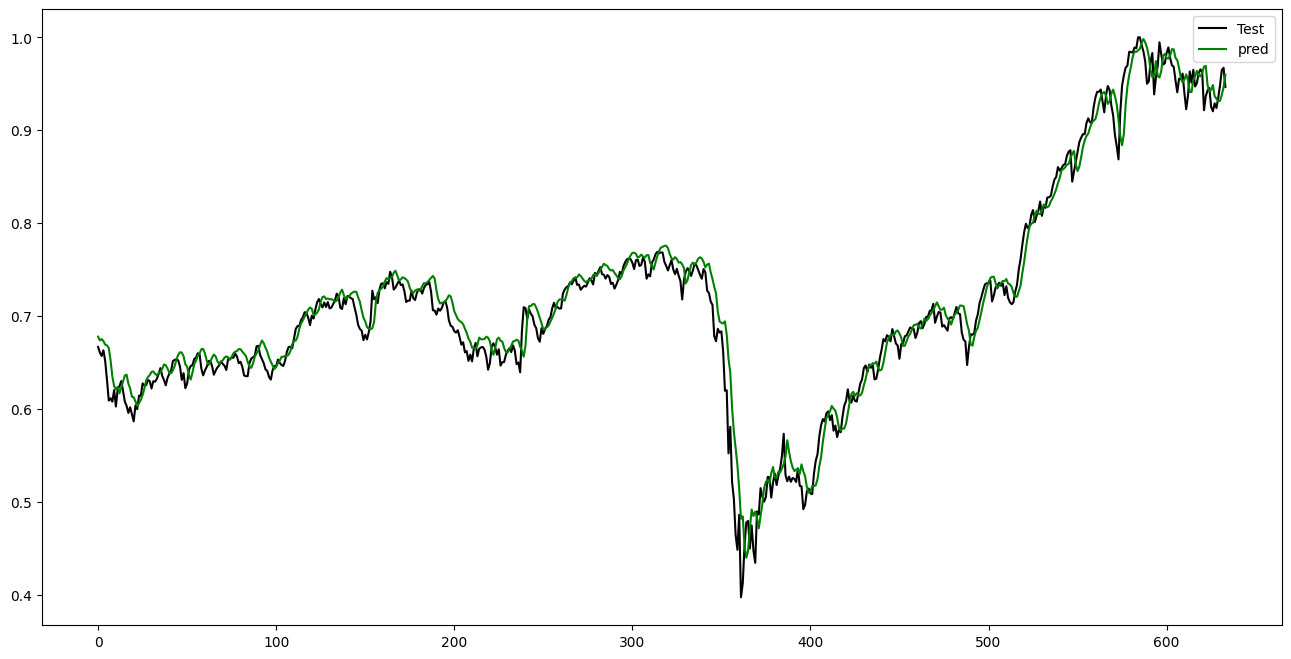

In [53]:
plt.figure(figsize=(16,8))
plt.plot(y_test, color = 'black', label = 'Test')
plt.plot(y_pred, color = 'green', label = 'pred')
plt.legend()
plt.show()

### Testing with nifty-100 data

In [99]:
df = pd.read_csv("nifty.csv")
df

,Date,Open,High,Low,Close,Adj Close
0,2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,4494.649902
1,2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,4546.200195
2,2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,4732.350098
3,2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,4747.549805
4,2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,4837.549805
...,...,...,...,...,...,...
3321,2021-04-26,14449.450200,14557.500000,14421.299810,14485.000000,14485.000000
3322,2021-04-27,14493.799810,14667.549810,14484.849610,14653.049810,14653.049810
3323,2021-04-28,14710.500000,14890.250000,14694.950200,14864.549810,14864.549810
3324,2021-04-29,14979.000000,15044.349610,14814.450200,14894.900390,14894.900390


In [100]:
df = generateFeatures(df)
df = df.drop(columns='index')
df

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390


In [101]:
df

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390


In [102]:
data_set = df.iloc[:, :]
data_set

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390


In [103]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)

[[0.1926454  0.19362549 0.21081316 ... 0.17139737 0.17744679 0.2022986 ]
 [0.19079251 0.1971284  0.21141358 ... 0.17461243 0.17635963 0.20057464]
 [0.19963566 0.19944422 0.21757185 ... 0.17705253 0.17590226 0.20885032]
 ...
 [0.93152905 0.94051273 0.94160794 ... 0.93771541 0.96587155 0.96480588]
 [0.94843517 0.95784828 0.95778116 ... 0.93978833 0.96810808 0.96717878]
 [0.96938253 0.96984378 0.96698008 ... 0.94252724 0.96838758 0.94655404]]


In [104]:
# Multiple features from the dataset are provided to the model
X = []

window = 10 # look-back period to predict the target closing price
for j in range(12):
    X.append([])
    for i in range(window, data_set_scaled.shape[0]):
        X[j].append(data_set_scaled[i - window:i, j])

# move axis from 0 to position 2
X = np.moveaxis(X, [0], [2])

X, yi = np.array(X), np.array(data_set_scaled[window:,-1])
y = np.reshape(yi,(len(yi), 1))

print(X.shape)
print(y.shape)

(3166, 10, 12)
(3166, 1)


In [105]:
y_pred = model.predict(X)
for i in range(len(X)):
    print(y_pred[i], y[i])

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[0.20297524] [0.19455454]
[0.19791639] [0.1902662]
[0.19424565] [0.19448419]
[0.19235437] [0.20257613]
[0.19179337] [0.20589502]
[0.19526288] [0.20177086]
[0.20021829] [0.20276376]
[0.2017433] [0.19555531]
[0.20186551] [0.18938664]
[0.19975115] [0.18379655]
[0.19533901] [0.18260426]
[0.1896298] [0.1871819]
[0.18560398] [0.18068878]
[0.18448733] [0.18340957]
[0.18294647] [0.17320668]
[0.18231358] [0.17135373]
[0.17869495] [0.1611665]
[0.17354493] [0.16830853]
[0.16766421] [0.1644658]
[0.16484322] [0.15454831]
[0.16461135] [0.15054922]
[0.1591507] [0.15631915]
[0.15363215] [0.15755053]
[0.1529594] [0.15581096]
[0.15284419] [0.16014229]
[0.15383902] [0.16643603]
[0.15623803] [0.1609163]
[0.15987673] [0.1548063]
[0.16138773] [0.14255501]
[0.15878542] [0.13621046]
[0.15201528] [0.1303233]
[0.14355916] [0.13513545]
[0.13625051] [0.14007663]
[0.13225268] [0.12606621]
[0.13385963] [0.11855284]
[0.1311379] [0.10731011]
[0.12483018] [0.12268091]
[0.11630579

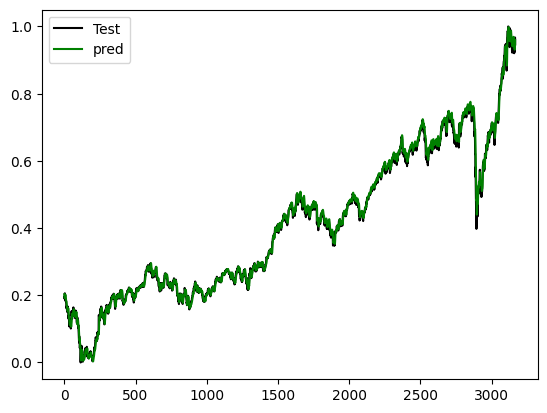

In [106]:
plt.plot(y, color = 'black', label = 'Test')
plt.plot(y_pred, color = 'green', label = 'pred')
plt.legend()
plt.show()

In [107]:
df['y_pred'] = np.nan
y_pred = np.array(y_pred)
df.loc[10:, 'y_pred'] = y_pred[:len(df) - 10]
df

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close,y_pred
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195,NaN
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902,NaN
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000,NaN
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902,NaN
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000,0.931131
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810,0.931681
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810,0.938240
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390,0.946209


In [108]:
# data_set_scaled.shape
df['close_scaled'] = data_set_scaled[:, 3]
df.head(20)

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close,y_pred,close_scaled
0,5022.899902,5072.700195,4991.350098,4999.850098,4849.053288,4884.465968,5119.190493,5132.886353,31.249455,-12.354105,5080.420906,4600.674016,5111.700195,NaN,0.193554
1,4999.149902,5117.700195,4999.149902,5111.700195,4872.886621,4906.107323,5119.042170,5132.605742,44.449983,-0.993287,5121.928854,4587.451078,5089.649902,NaN,0.202299
2,5112.500000,5147.450195,5079.149902,5089.649902,4894.089941,4923.587569,5118.460145,5132.036790,52.526727,9.710716,5153.431744,4581.888178,5195.500000,NaN,0.200575
3,5092.399902,5210.899902,5082.149902,5195.500000,4930.656608,4949.483991,5119.985687,5132.877362,66.699948,21.108562,5198.789698,4561.880224,5165.899902,NaN,0.208850
4,5198.350098,5230.750000,5155.850098,5165.899902,4957.636589,4970.095030,5120.894879,5133.314747,74.682948,31.823440,5235.983181,4567.826731,5228.200195,NaN,0.206536
5,5265.299805,5298.850098,5197.600098,5228.200195,4992.206608,4994.676474,5123.019737,5134.571508,85.056172,42.469986,5280.233429,4572.441522,5192.250000,NaN,0.211407
6,5227.250000,5254.500000,5182.600098,5192.250000,5021.886621,5013.493001,5124.390633,5135.335461,89.346219,51.845233,5310.923182,4585.556750,5144.649902,NaN,0.208596
7,5192.350098,5206.500000,5110.899902,5144.649902,5049.329948,5025.984134,5124.791807,5135.458832,87.892017,59.054590,5329.690606,4604.094306,5135.500000,NaN,0.204875
8,5156.700195,5159.049805,5101.250000,5135.500000,5073.176628,5036.414216,5125.003850,5135.459377,85.021160,64.247904,5329.630387,4653.004525,5081.700195,NaN,0.204159
9,5135.799805,5143.049805,5062.450195,5081.700195,5086.646647,5040.727167,5124.146352,5134.747335,77.511289,66.900581,5330.562898,4684.122014,4982.600098,NaN,0.199953


In [109]:
conditions = [df.close_scaled < df.y_pred, df.close_scaled > df.y_pred]

choices = ['Buy', 'Sell']

df['signal'] = np.select(conditions, choices)

df.dropna(inplace = True)

In [110]:
df

,Open,High,Low,Adj Close,rsi,ema_fast,ema_medium,ema_slow,macd,macd_signal,bb_high,bb_low,target_next_close,y_pred,close_scaled,signal
10,5070.850098,5087.649902,4969.399902,4982.600098,5093.000000,5035.191255,5121.343456,5132.732140,62.838746,66.088214,5314.460069,4727.519863,5012.649902,0.202975,0.192205,Buy
11,4981.000000,5021.750000,4913.799805,5012.649902,5096.616667,5033.044460,5119.191108,5131.141646,53.024189,63.475409,5299.646187,4768.893754,4957.799805,0.197916,0.194555,Buy
12,5008.600098,5066.000000,4943.750000,4957.799805,5091.336654,5025.878302,5115.995241,5128.845728,40.354950,58.851317,5275.588219,4815.431703,5011.750000,0.194246,0.190266,Buy
13,4958.450195,5026.100098,4932.049805,5011.750000,5088.833333,5024.532750,5113.930979,5127.294791,34.272742,53.935602,5252.867583,4861.547358,5115.250000,0.192354,0.194484,Sell
14,5010.899902,5118.549805,4999.600098,5115.250000,5094.996680,5033.172488,5113.957098,5127.135257,37.373317,50.623145,5248.141751,4889.833200,5157.700195,0.191793,0.202576,Sell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,14326.349610,14461.150390,14273.299810,14341.349610,14588.353258,14577.329093,14162.653399,13680.497549,-108.135681,-75.570603,14994.889716,14191.785191,14485.000000,0.931131,0.923901,Buy
3172,14449.450200,14557.500000,14421.299810,14485.000000,14574.639911,14568.535846,14169.036500,13691.153211,-101.594515,-80.775385,14967.617872,14186.082035,14653.049810,0.931681,0.935132,Sell
3173,14493.799810,14667.549810,14484.849610,14653.049810,14560.353258,14576.584795,14178.620922,13703.893563,-81.906214,-81.001551,14973.954256,14190.110593,14864.549810,0.938240,0.948270,Sell
3174,14710.500000,14890.250000,14694.950200,14864.549810,14575.469925,14604.010034,14192.203672,13719.266493,-48.675708,-74.536382,15000.716753,14217.313038,14894.900390,0.946209,0.964806,Sell


In [111]:
# Signal is based on the Close of a day and we buy the stock at the Open of the next day
df['signal_shifted'] = df['signal'].shift()

In [112]:
# Ensuring that we Buy before we Sell
position  = False

buydates, selldates = [], []
buyprices, sellprices = [], []

for index, row in df.iterrows():
    if not position and row['signal_shifted'] == 'Buy':
        buydates.append(index)
        buyprices.append(row.Open)
        position = True

    if position:
        if row['signal_shifted'] == 'Sell':
            selldates.append(index)
            sellprices.append(row.Open)
            position = False

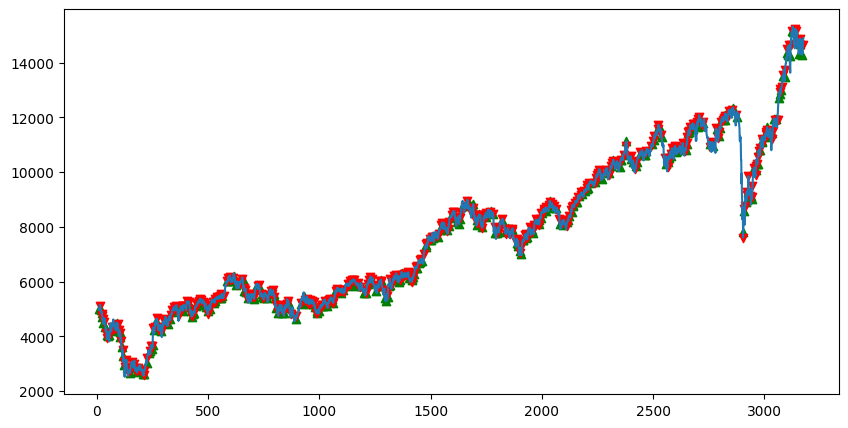

In [116]:
plt.figure(figsize = (10, 5))
plt.plot(df['Adj Close'])
plt.scatter(df.loc[buydates].index, 
            df.loc[buydates]['Adj Close'], 
            marker = '^', color = 'green')

plt.scatter(df.loc[selldates].index, 
            df.loc[selldates]['Adj Close'], 
            marker = 'v', color = 'red')

In [117]:
(pd.Series([(sell - buy) / buy for sell, buy in zip(sellprices, buyprices)])+1).prod()

1.206923875463806